In [71]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from matplotlib.animation import FuncAnimation
import re
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.interpolate import interp1d
import math
from tqdm import tqdm
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit

In [72]:
#Параметры разных типов сосудов. Удобно, что в модели можно менять название сосуда и автоматически везде подставятся нужны геометрические значения
vessels_params = {
   "arteriole": {
    "r_m": 30e-6,           # радиус ~30 µm
    "L_m": 3e-3,            # длина сегмента ~3 мм***
    "Q_m3_s": 1.5e-11,      # поток ~0.5–1e-12 м³/с
    "Q_pulse_frac": 0.1,
    "f_Hz": 1,
    "mu_Pa_s": 0.0035
}
,
    "small_artery": {
    "r_m": 0.25e-3,        
    "L_m": 0.02,            
    "Q_m3_s": 5e-9,         
    "Q_pulse_frac": 0.15,
    "f_Hz": 1,
    "mu_Pa_s": 0.0035
}
,
    "medium_artery": {
        "r_m": 3e-3,           
        "L_m": 0.03,            
        "Q_m3_s": 1e-5,         
        "Q_pulse_frac": 0.2,
        "f_Hz": 1,
        "mu_Pa_s": 0.0035
    },
    "aorta": {
        "r_m": 0.012,           
        "L_m": 0.1,             
        "Q_m3_s": 5e-5,         
        "Q_pulse_frac": 0.3,
        "f_Hz": 1,
        "mu_Pa_s": 0.0035
    }
}

In [73]:
#Функция, которая описывает откачку Ca из сосуда
def calcium_fluxes(Ca, Cab): #A mathematical model of cytosolic calcium dynamics in human umbilical vein endothelial cells 

    # ===== Буфферизация =====
    BT = 120e-6          # 120 µM
    k6 = 100 * 1e6           # M⁻¹ s⁻¹
    k7 = 300             # s⁻¹
    # ===== Ca-ATPase =====
    Vp = 1.63e-6         # 1.63 µM/s
    Vhi = 4.76e-6        # 2.38 µM/s
    K4 = 0.08e-6         # 0.08 µM
    Khi = 0.38e-6        # 0.38 µM

    # ===== Na/Ca exchanger =====
    Vex = 18.33e-6       # 18.33 µM/s
    K5 = 0.321e-6        # 0.321 µM
    # ===== ЭПР =====
    k4 = 5.0e-6
    K3 = 0.15e-6 
    # ===== Буферизация =====
    q_b = k6 * Ca * (BT - Cab) - k7 * Cab

    # ===== Ca-ATPase =====
    q_ATPase = (
        Vp * Ca**1.7 / (K4**1.7 + Ca**1.7)
        + Vhi * Ca**4.4 / (Khi**4.4 + Ca**4.4)
    )

    # ===== Na/Ca exchanger =====
    q_ex = Vex * Ca / (K5 + Ca)
    # ===== ЭПР =====


    # ===== Общий вывод =====
    q_pump = q_ATPase + q_ex

    return q_pump, q_b

In [74]:
def piezo1_open_probability(tau_dyn_cm2, vessel_type):
    kB         = 1.380649e-23
    T_kelvin   = 310.0
    kBT        = kB * T_kelvin
    delta_g0_kT = 7.0
    delta_a_nm2 = 20.0
    tau_SI     = tau_dyn_cm2 * 0.1
    p = vessels_params[vessel_type]
    r_SI = p["r_m"]
    alpha = 50
    T_membrane = alpha * tau_SI * r_SI / 2.0
    delta_a_SI = delta_a_nm2 * 1e-18
    delta_g0_J = delta_g0_kT * kBT
    delta_G    = delta_g0_J - delta_a_SI * T_membrane
    return 1.0 / (1.0 + np.exp(delta_G / kBT))

In [75]:
#модель изменения концентрации Ca внутри клетки Atherosclerosis and calcium signalling in endothelial cells
def ca_model(t, y, vessel_type, tau=5):
    Ca_c, Ca_s, Cab, N_open, N_inact, N_cl, IP3, G, PIP2 = y

    tau_shear = tau
    tau_inact = 0.0656 # Piezo1, a mechanically activated ion channel, is required for vascular development in mice
    k_inact = 1.0 / tau_inact
    tau_rec = 0.024 # Transduction of repetitive mechanical stimuli by Piezo1 and Piezo2 ion channels
    k_rec = 1.0 / tau_rec
    tau_open  = 1
    Vc = 1835e-15 # л³  The shape of the EC varies along the vascular tree, but they are generally thin and slightly elongated, their dimensions described to be roughly 30–50 µm in length, 10–30 µm wide and a thickness of 0.1–10 µm
    #Endothelial cell subpopulations in vitro: cell volume, cell cycle, and radiosensitivity 1,009 +- 170   1,835 +- 282
    N_s = 1 # каналов на клетку, 1-2 канала/мкм,2 Piezo1 ion channels inherently function as independent mechanotransducers
    V_um3 = Vc * 1e15

    # площадь поверхности в мкм^2
    S = 4 * math.pi * ((3 * V_um3) / (4 * math.pi)) ** (2/3)
    N_total = round(N_s * S,0) # каналов на клетку, 1-2 канала/мкм,2 Piezo1 ion channels inherently function as independent mechanotransducers
    # ===== P_0 =====
    p_o = piezo1_open_probability(tau_shear,vessel_type)
    # ===== k_open с Wiesner sensitization A mathematical model of the cytosolic-free calcium response in endothelial cells to fluid shearstress =====
    k_open = 1 / tau_open * p_o # A mathematical model of the cytosolic-free calcium response in endothelial cells to fluid shearstress в статье говорится, что константа открытия как раз пропорциональна вероятности открытия

    dN_open_dt  = k_open * N_cl - k_inact * N_open
    dN_inact_dt = k_inact * N_open - k_rec * N_inact
    dN_cl_dt    = k_rec * N_inact - k_open * N_cl

    R, T_phys, F = 8.314, 310.0, 96485.0
    Vm = -40e-3 # V Contributions of K+, Na+, and Cl- to the membrane potential of intact hamster vascular endothelial cells
    Ca_o = 1.5e-3
    z = 2.0

    
    f_g_tot = 41.3e-12 #Voltage gating of mechanosensitive PIEZO channels 41.3 ± 0.9 pS
    Na_o = 145*1e-3
    N_o = 5*1e-3
    PCa = 1.06 # PCa/PCs ratio of 1.21 Piezo1 ion channel pore properties are dictated by C-terminal region
    #PK > PCs 1.0: 0.88 Ionic Selectivity and Permeation Properties of Human PIEZO1 Channels
    PNa = 1
    PK = 1.22
    f_Ca = 4 * PCa*Ca_o/ (4 * PCa*Ca_o + PNa*Na_o + PK * N_o)
    P_tot = f_g_tot * R * T_phys / (z**2 * F**2 * Ca_o)
    # Поток через все открытые каналы (моль/с) A mathematical model of the cytosolic-free calcium response in endothelial cells to fluid shearstress
    exp_term = np.exp(-z * F * Vm / (R * T_phys))
    q_in_i = -N_open * P_tot * f_Ca * z**2 * F**2 * Vm / (R * T_phys) * (Ca_c - Ca_o * exp_term) / (1.0 - exp_term)
    q_in = q_in_i / (z * F * Vc)

    # ===== 8. AKT & PKC dynamics =====
    k_pkc = 0.1155
    k_akt = 0.1155
    Lambda = 15
    k_a = 0.017      # ka
    k_d = 0.15       # kd
    G_t = 0.33*1e-6
    rr = 10
    alpha = 8.37
    K_cp = 0.002*1e6
    M_ATP = 0.7937
    k_pip2_minus = 0.7024
    k_1p = 0.021
    alpha_PI3K = 2.5
    eta = 0.003
    delta = 24
    k_2p = 0.022
    k_pip2_plus = k_1p + k_2p
    mu1 = 0.2
    PIP2_t = 10*1e-6


    PIP3_min = 0.0031 * PIP2_t
    R_star = np.tanh(np.pi * tau_shear / Lambda)
    PIP3_max = 0.031 * PIP2_t
    dG_dt = k_a * R_star * (G_t - G) - k_d * G
    
    rf = alpha * K_cp * M_ATP * G

    dIP3_dt = rf * PIP2  - mu1 * IP3

    dPIP2_dt = - (rf + rr) * PIP2 - rr * IP3 + rr * PIP2_t - k_pip2_plus * PIP2 + k_pip2_minus * IP3



    k3 = 6.64 #6.64
    k5 = 1e-1
    K_CICR = 0.0
    K2 = 0.2e-6
    V_r = 3.5
    k4 = 5.0e-6
    K3 = 0.15e-6
    
    q_rel = k3 * Ca_c / (K_CICR + Ca_c + 1e-30) * (IP3 / (K2 + IP3))**3 * Ca_s #Atherosclerosis and calcium signalling in endothelial cells
    q_SERCA = k4 * (Ca_c / (K3 + Ca_c))**2 #Atherosclerosis and calcium signalling in endothelial cells

    q_out, q_b = calcium_fluxes(Ca_c, Cab)

    kCCE = 15e-1
    Cas0 = 2.828e-3
    q_cce = kCCE * (Cas0 - Ca_s) * (Ca_o - Ca_c) #Atherosclerosis and calcium signalling in endothelial cells
    k8 = 24.7e-6
    q_sink = k8 * Ca_c / (1.0 + Ca_c)
    q_leak = k5 * Ca_s**2
    dCa_c_dt = q_rel + q_in + q_cce + q_leak - q_SERCA  - q_out - q_b  - q_sink  #Atherosclerosis and calcium signalling in endothelial cells
    dCa_s_dt = -V_r * (q_rel - q_SERCA + q_leak) #Atherosclerosis and calcium signalling in endothelial cells
    dCab_dt = q_b #Atherosclerosis and calcium signalling in endothelial cells
    '''print(
    f"t={t:.2f} | Ca={Ca_c*1e9:.3f} нM | "
    f"rel={q_rel*1e6:.3f} in={q_in*1e6:.3f} cce={q_cce*1e6:.3f} "
    f"leak={q_leak*1e6:.3f} SERCA={q_SERCA*1e6:.3f} "
    f"out={q_out*1e6:.3f} buf={q_b*1e6:.3f} sink={q_sink*1e6:.3f}")'''
    return [dCa_c_dt, dCa_s_dt, dCab_dt, dN_open_dt, dN_inact_dt, dN_cl_dt, dIP3_dt, dG_dt, dPIP2_dt]

In [76]:
# Модель NO
#Shear‑Induced Nitric Oxide Production by Endothelial Cells
def no_model(t, y, Ca_profile, vessel_type, tau=5):
    Ca4CaM, eNOS_CaM, eNOS_CaM_star, eNOS0cav, NO, cGMP, AKT_star, PKC_star, G, IP3, PIP2, PIP3 = y

    # ===== Входные параметры =====
    Ca = Ca_profile(t) # + 5*1e-9                      # моль/л (M)

    tau_shear = tau

    # CaM (Eq.17): первоначально в µM → умножаем на 1e-6
    k_Ca4_CaM   = 100.0        # s⁻¹
    beta        = 2.7
    theta       = 0.0045 #0.0045
    K_d_CaM     = 1e-6  # 1 µM → 1e-6 M
    CaM_tot     = 30e-6  # 30 µM → 30e-6 M

    # eNOS‑CaM (Eq.18)
    k_plus_CaM      = 7.5      # s⁻¹
    k_minus_CaM     = 0.01     # s⁻¹
    K_0_5_CaM       = 3e-6  # 3 µM → 3e-6 M
    eNOS_tot        = 0.04e-6 # 0.04 µM → 0.04e-6 M

    # eNOS‑CaM* (Eq.19)
    k_eAKT_max      = 0.004        # s⁻¹
    k_eAKT_minus    = 2.22e-4      # s⁻¹
    k_eAKT_plus = k_eAKT_max * AKT_star

    # PKC inhibition (Eq.20)
    k_Thr_plus      = 0.002
    k_Thr_minus     = 2.22e-4

    # NO production (Eq.22–26)
    Upsilon_base         = 300.0#300.0
    sigma = 1
    A = 700.0
    delta_like = A  * np.exp(-(tau**2) / (2 * sigma**2))
    Upsilon = Upsilon_base + delta_like
    phi             = 9.0
    R_max_NO        = 0.022
    lambda_NO       = 382.0

    # a0, a1, b1, g0, g1: изначально в nM → нужно пересчитать в M
    a0 = 1200.16 * 1e-18   # nM² → M²: 1 nM² = 1e-18 M²
    a1  = 37.33 * 1e-9      # nM  → 1e-9 M
    b1  = 15.15 * 1e-9    # nM  → 1e-9 M
    g0 = 4.8 * 1e-18      # nM² → 1e-18 M²
    g1  = 35.33  * 1e-9    # nM  → 1e-9 M

    sGC_tot         = 0.1e-6   # 0.1 µM → 0.1e-6 M

    # cGMP (Eq.27)
    V_max_cGMP      = 1.26e-6         # µM/s → нужно в M/s

    X               = 0.0695          # s⁻¹ 
    K_cGMP          = 2e-6    # 2 µM → 2e-6 M (в M)

    # ===== 8. AKT & PKC dynamics =====
    k_pkc = 0.1155
    k_akt = 0.1155
    Lambda = 15
    k_a = 0.017      # ka
    k_d = 0.15       # kd
    G_t = 0.33*1e-6
    rr = 10
    alpha = 8.37
    K_cp = 0.002*1e6
    M_ATP = 0.7937
    k_pip2_minus = 0.7024
    k_1p = 0.021
    alpha_PI3K = 2.5
    eta = 0.003
    delta = 24
    k_2p = 0.022 #0.022 
    k_pip2_plus = k_1p / (1 + alpha_PI3K) * (1 + alpha_PI3K * np.exp(-eta * t)*np.tanh(np.pi * tau_shear / delta)) + k_2p
    k_pip2_plus = k_1p + k_2p
    mu1 = 0.2
    PIP2_t = 10*1e-6

    AKT = 1 - AKT_star
    PKC = 1 - PKC_star
    PIP3_min = 0.0031 * PIP2_t
    PIP3_max = 0.031 * PIP2_t
    R_star = np.tanh(np.pi * tau_shear / Lambda)
    kpkc = 0.1 * k_pkc * (PIP3 - PIP3_min)/(PIP3_max - PIP3_min)
    kakt = 0.1 * k_akt * (PIP3 - PIP3_min)/(PIP3_max - PIP3_min)

    # ===== 1. Ca4‑CaM =====
    dCa4CaM_dt = k_Ca4_CaM * (theta * Ca**beta / (K_d_CaM**beta + Ca**beta) * CaM_tot -  Ca4CaM) # The Relationship between the Free Concentrations of Ca21 and Ca21-calmodulin in Intact Cells*

    # ===== 2. eNOS_cav =====
    eNOS_cav = eNOS_tot - eNOS_CaM - eNOS_CaM_star - eNOS0cav

    # ===== 4. eNOS‑CaM* (phosphorylation by AKT) =====
    d_eNOS_CaM_star_dt  = k_eAKT_plus * eNOS_CaM - k_eAKT_minus * eNOS_CaM_star

    # ===== 3. eNOS‑CaM =====
    d_eNOS_CaM_dt = k_plus_CaM * (Ca4CaM / (K_0_5_CaM + Ca4CaM)) * eNOS_cav- k_minus_CaM * eNOS_CaM - d_eNOS_CaM_star_dt
    
    # ===== 5. PKC inhibition → eNOS0cav =====
    d_eNOS0cav_dt = k_Thr_plus * PKC_star * eNOS_cav - k_Thr_minus * eNOS0cav
    
    # ===== 6. NO production =====
    R_NO        = Upsilon * (eNOS_CaM + phi * eNOS_CaM_star)
    denom_sGC   = a0 + a1 * NO + NO**2
    Q_sGC       = R_max_NO * (NO**2 + b1 * NO) / denom_sGC * sGC_tot
    d_NO_dt     = R_NO - Q_sGC - lambda_NO * NO
    
    # ===== 7. cGMP =====
    dcGMP_dt    = V_max_cGMP * (g0 + g1 * NO + NO**2) / (a0 + a1 * NO + NO**2) - X * (cGMP**2 / (K_cGMP + cGMP))

    K_cGMP = 0.55*1e-6#Mathematical Modeling of the Nitric Oxide/cGMP Pathways in the Vascular Smooth Muscle Cell
    dcGMP_dt    = V_max_cGMP * (g0 + g1 * NO + NO**2) / (a0 + a1 * NO + NO**2) - X * (cGMP**2 / (K_cGMP**2  + cGMP**2))
    # ===== 8. AKT & PKC dynamics =====
    dG_dt = k_a * R_star * (G_t - G) - k_d * G
    rf = alpha * K_cp * M_ATP * G
    dIP3_dt = rf * PIP2 - mu1 * IP3
    dPIP2_dt = - (rf + rr) * PIP2 - rr * IP3 + rr * PIP2_t - k_pip2_plus * PIP2 + k_pip2_minus * PIP3
    dPIP3_dt = k_pip2_plus * PIP2 - k_pip2_minus * PIP3
    d_AKT_star_dt = kakt * AKT - k_akt * AKT_star
    d_PKC_star_dt = kpkc * PKC - k_pkc * PKC_star
    dPIP3_dt = k_pip2_plus * PIP2 - k_pip2_minus * PIP3

    return [
    dCa4CaM_dt,
    d_eNOS_CaM_dt,
    d_eNOS_CaM_star_dt,
    d_eNOS0cav_dt,
    d_NO_dt,
    dcGMP_dt,
    d_AKT_star_dt,
    d_PKC_star_dt,
    dG_dt,
    dIP3_dt,
    dPIP2_dt,
    dPIP3_dt
]


In [77]:
#Профиль скоростей
# Выбираем тип сосуда
vessel_type = "arteriole" 

In [78]:
k5 = 1e-1
k4 = 5.0e-6
K3 = 0.15e-6
BT = 120e-6
k6 = 100e6
k7 = 300

Ca0 = 50e-9 #Shear-Induced Nitric Oxide Production by Endothelial Cells
Cs0 = (k4/k5)**(1/2)*(Ca0/(K3+Ca0))
Cab0 = k6*Ca0*BT/(k6*Ca0 + k7)
IP30 = 0
Vc = 1835e-15 # л³  The shape of the EC varies along the vascular tree, but they are generally thin and slightly elongated, their dimensions described to be roughly 30–50 µm in length, 10–30 µm wide and a thickness of 0.1–10 µm
#Endothelial cell subpopulations in vitro: cell volume, cell cycle, and radiosensitivity 1,009 +- 170   1,835 +- 282
N_s = 1 # каналов на клетку, 1-2 канала/мкм,2 Piezo1 ion channels inherently function as independent mechanotransducers
V_um3 = Vc * 1e15

    # площадь поверхности в мкм^2
S = 4 * math.pi * ((3 * V_um3) / (4 * math.pi)) ** (2/3)
N_total = round(N_s * S,0)
N_op0 = 0.0
N_inact0 = 0.0
N_cl0 = N_total - N_op0 - N_inact0   # закрытые
G0 = 0
PIP20 = 10e-6 #Shear‑Induced Nitric Oxide Production by Endothelial Cells Basal (initial) conditions


y0 = [Ca0, Cs0, Cab0, N_op0, N_inact0, N_cl0, IP30, G0, PIP20]


In [79]:

# Все параметры Shear-Induced Nitric Oxide Production by Endothelial Cells

# ===== Ca–CaM путь =====
Ca4CaM0 = 0.00026e-6

# ===== eNOS состояния =====
eNOS_CaM0 = 0.0019e-6
eNOS_CaM_star0 = 0.001e-6
eNOS0cav0 = 0.0078e-6#0.0078e-6

# ===== NO и downstream =====
NO0 = 0.0089e-6
cGMP0 = 3.8624e-6

# ===== AKT / PKC =====
AKT_star0 = 0
PKC_star0 = 0

# ===== upstream G-protein / mechanotransduction =====
G0 = 0

# ===== IP3 / Ca²⁺ signaling =====
IP30 = 0

# ===== phosphoinositides =====
PIP20 = 10e-6
PIP30 = 0.116e-6

y0_no = [
    Ca4CaM0,
    eNOS_CaM0,
    eNOS_CaM_star0,
    eNOS0cav0,
    NO0,
    cGMP0,
    AKT_star0,
    PKC_star0,
    G0,
    IP30,
    PIP20,
    PIP30
]

In [ ]:
%%time
tau_values = [0, 0.1, 0.2, 0.5, 1,1.5, 1.8, 1.9, 2,2.5, 3, 4, 5, 6,6.75, 7, 8, 9, 10, 10.1, 11,  12,13.5, 14, 16, 20, 24]
#tau_values = [0, 0.1,   6, 6.75,  10,  10.1, 13.5]
#tau_values = [0, 0.1, 0.2,  0.5, 1,1.5, 1.8, 1.9, 2,2.5, 3, 4, 5, 6,6.75, 7, 8, 9, 10, 10.1, 11]
#tau_values = [11,  12,13.5, 14, 16, 20, 24]
#tau_values = [0, 0.1, 1, 2, 3, 4, 7, 8, 9, 10, 10.1, 13.5, 14, 16,  24]
#tau_values = [0, 0.1, 6 , 10, 10.1, 13.5]
Ca_plateau = []
NO_plateau = []
R_NO_plateau = []
R_NO_plateau_mean = []
R_NO_max_time = []
solutions_no = {}
solutions_Ca = {}

for tau in tqdm(tau_values):
    t_total = 20000 if tau < 2 else 8000
    max_step = 0.5 if tau < 2 else 1.0
    # ===== Ca =====
    sol_ca = solve_ivp(
        fun=lambda t, y: ca_model(t, y, vessel_type, tau),
        t_span=(0, t_total),
        y0=y0,
        max_step=max_step,
        method="BDF",
        dense_output=True
    )
    
    t_ca = sol_ca.t
    Ca = sol_ca.y[0]
    
    # плато Ca
    Ca_ss = np.mean(Ca[-100:])
    Ca_plateau.append(Ca_ss)
    
    # ===== Интерполяция Ca =====
    Ca_interp = lambda t: sol_ca.sol(t)[0]
    
    # ===== NO =====
    sol_no = solve_ivp(
        fun=lambda t, y: no_model(t, y, Ca_interp, vessel_type, tau),
        t_span=(0, t_total),
        y0=y0_no,
        max_step=max_step,
        method="BDF"
    )
    
    NO = sol_no.y[4]  
    solutions_no[tau] = sol_no
    solutions_Ca[tau] = sol_ca
    
    # плато NO
    NO_ss = np.mean(NO[-10:])
    NO_plateau.append(NO_ss)
    # ===== R_NO =====
    t_no = sol_no.t
    eNOS_CaM = sol_no.y[1]
    eNOS_CaM_star = sol_no.y[2]

    Upsilon_base = 300.0
    sigma = 1
    delta_like = 700.0 * np.exp(-(tau**2) / (2 * sigma**2))
    Upsilon = Upsilon_base + delta_like
    phi = 9.0
    R_NO = Upsilon * (eNOS_CaM + phi * eNOS_CaM_star)
    
    # плато NO
    R_NO_ss_mean = np.mean(R_NO[-10:])
    R_NO_ss = np.max(R_NO)
    R_NO_plateau.append(R_NO_ss)
    R_NO_plateau_mean.append(R_NO_ss_mean)
    
    idx_max = np.argmax(R_NO)
    t_max_R_NO = t_no[idx_max]
    R_NO_max_time.append(t_max_R_NO)
print(R_NO_max_time)

 22%|█████████▊                                  | 6/27 [00:32<01:51,  5.31s/it]

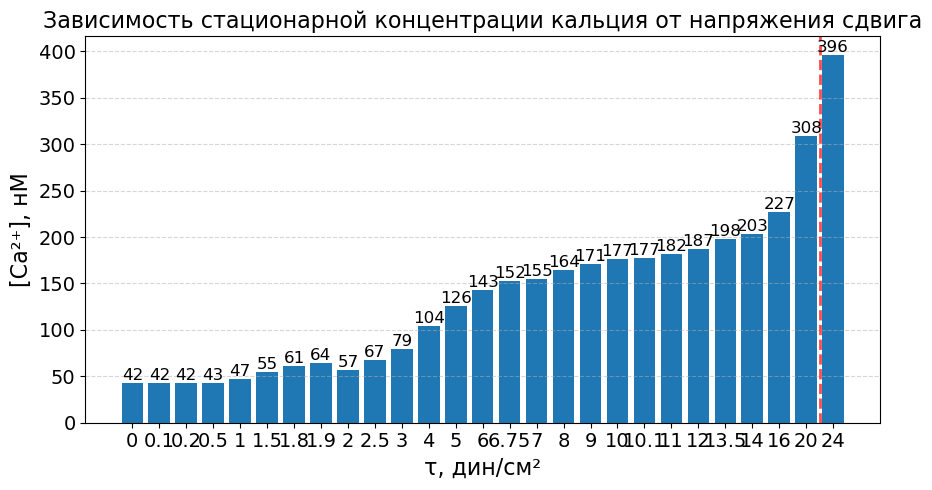

CPU times: user 279 ms, sys: 27.1 ms, total: 306 ms
Wall time: 368 ms


In [25]:
%%time
# позиции столбцов (равномерные)
x_pos = np.arange(len(tau_values))

plt.figure(figsize=(9,5))

bars = plt.bar(x_pos, np.array(Ca_plateau)*1e9)

# подписи оси X (твои tau)
plt.xticks(x_pos, tau_values, fontsize=14)  # размер шрифта для отметок
plt.yticks(fontsize=14)
title_text = 'Зависимость стационарной концентрации кальция от напряжения сдвига'
plt.xlabel('τ, дин/см²', fontsize=16)
plt.ylabel('[Ca²⁺], нМ', fontsize=16)
plt.title(title_text, fontsize=16)  # увеличиваем и делаем жирным

# ===== ВЕРТИКАЛЬНАЯ ЛИНИЯ =====
plt.axvline(
    x=len(tau_values) - 1.5,
    color='red',
    linestyle='--',
    linewidth=2,
    alpha=0.7
)

# подписи значений над столбцами
for i, v in enumerate(Ca_plateau):
    plt.text(i, v*1e9, f"{v*1e9:.0f}", ha='center', va='bottom', fontsize=12)

# немного "красоты"
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# ===== Создаем "чистое" имя файла =====
import re
file_name = re.sub(r'[^\w\-_\. ]', '_', title_text)  # заменяем недопустимые символы на "_"
file_name = file_name.replace(' ', '_')               # заменяем пробелы на "_"
file_name += '.png'

# сохраняем
plt.savefig(file_name, dpi=300, bbox_inches='tight')
plt.show()

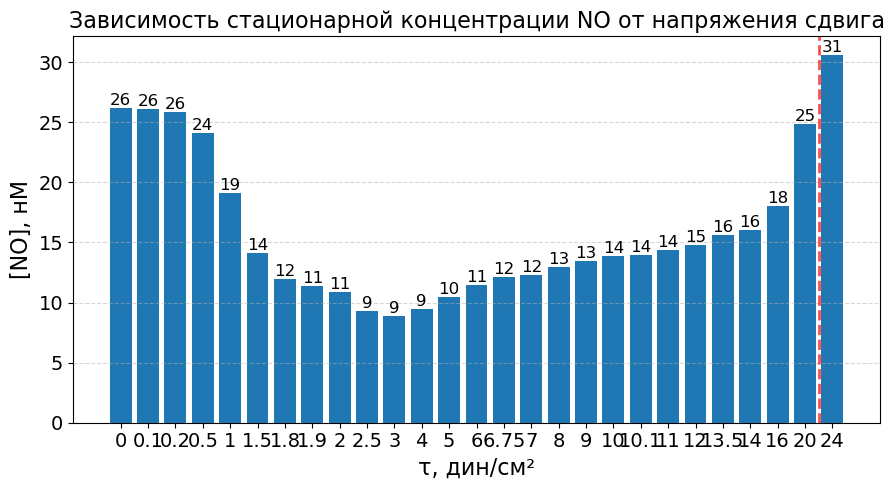

CPU times: user 230 ms, sys: 8.88 ms, total: 238 ms
Wall time: 237 ms


In [26]:
%%time
# позиции столбцов (равномерные)
x_pos = np.arange(len(tau_values))

plt.figure(figsize=(9,5))

bars = plt.bar(x_pos, np.array(NO_plateau)*1e9)

# подписи оси X и Y
plt.xticks(x_pos, tau_values, fontsize=14)
plt.yticks(fontsize=14)

# заголовок и подписи осей
title_text = 'Зависимость стационарной концентрации NO от напряжения сдвига'
plt.xlabel('τ, дин/см²', fontsize=16)
plt.ylabel('[NO], нМ', fontsize=16)
plt.title(title_text, fontsize=16)

# ===== ВЕРТИКАЛЬНАЯ ЛИНИЯ =====
plt.axvline(
    x=len(tau_values) - 1.5,
    color='red',
    linestyle='--',
    linewidth=2,
    alpha=0.7
)

# подписи значений над столбцами
for i, v in enumerate(NO_plateau):
    plt.text(i, v*1e9, f"{v*1e9:.0f}", ha='center', va='bottom', fontsize=12)

# немного "красоты"
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# ===== Создаем "чистое" имя файла =====
import re
file_name = re.sub(r'[^\w\-_\. ]', '_', title_text)
file_name = file_name.replace(' ', '_')
file_name += '.png'

# сохраняем
plt.savefig(file_name, dpi=300, bbox_inches='tight')
plt.show()

In [27]:
%%time
# значения τ, которые оставляем
tau_selected = [0.1, 6, 10]
# индексы этих значений
indices = [tau_values.index(t) for t in tau_selected]

# отфильтрованные данные
NO_shifted = np.array(NO_plateau) - NO_plateau[0]
NO_selected = NO_shifted[indices]

x_pos_sel = np.arange(len(tau_selected))


CPU times: user 69 μs, sys: 16 μs, total: 85 μs
Wall time: 91.1 μs


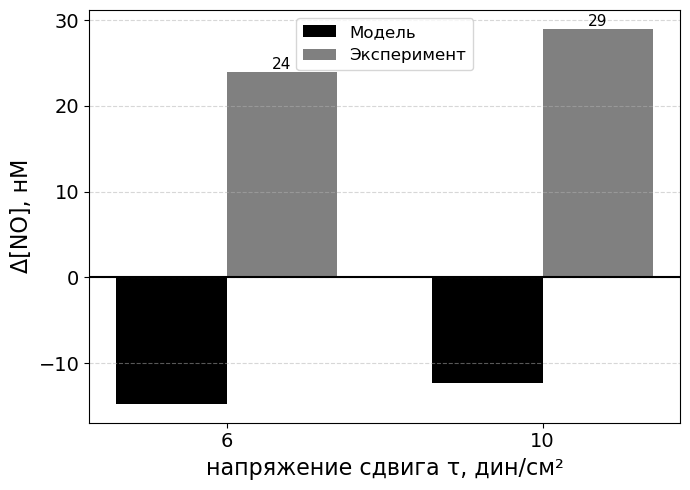

In [28]:
# ===== Выбранные значения shear stress =====

# индексы в массиве tau_values
indices = [tau_values.index(t) for t in tau_selected]

# ===== Модель =====

NO_shifted = np.array(NO_plateau) - NO_plateau[0]
indices_clear = [tau_values.index(t) for t in tau_selected][1:]
NO_model_nM = NO_shifted[indices_clear] * 1e9
tau_selected_clear = tau_selected[1:]
# ===== Эксперимент =====
# значения сняты с графика

NO_exp_nM = np.array([
    24,   # 0.1 -> 6
    29   # 0.1 -> 10

])

# ===== Позиции столбцов =====

x_pos_sel = np.arange(len(tau_selected_clear))

width = 0.35

# ===== График =====

plt.figure(figsize=(7,5))

# модель — чёрные
plt.bar(
    x_pos_sel - width/2,
    NO_model_nM,
    width=width,
    color='black',
    label='Модель'
)

# эксперимент — серые
plt.bar(
    x_pos_sel + width/2,
    NO_exp_nM,
    width=width,
    color='gray',
    label='Эксперимент'
)

# ===== Оси =====

plt.xticks(x_pos_sel, tau_selected_clear, fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('напряжение сдвига τ, дин/см²', fontsize=16)
plt.ylabel('Δ[NO], нМ', fontsize=16)

plt.title('',
          fontsize=15)

# линия нуля
plt.axhline(y=0, color='black', linewidth=1.5)

# ===== Подписи =====

for i, v in enumerate(NO_model_nM):
    plt.text(
        x_pos_sel[i] - width/2,
        v,
        f'{v:.0f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

for i, v in enumerate(NO_exp_nM):
    plt.text(
        x_pos_sel[i] + width/2,
        v,
        f'{v:.0f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.legend(fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(
    'NO_step_change_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

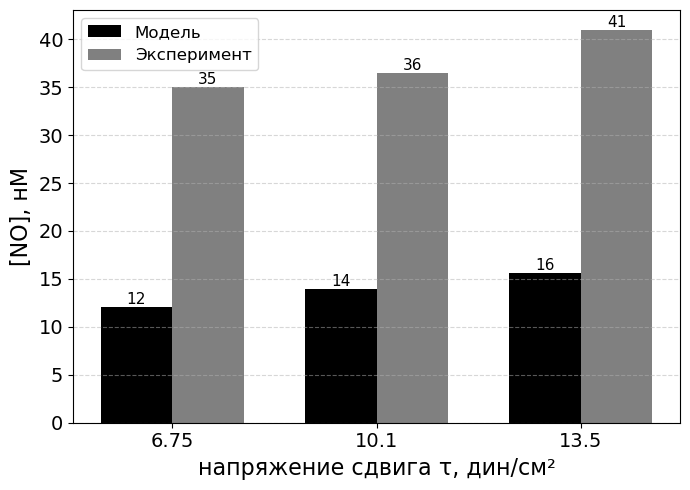

In [29]:
# ===== Выбранные значения shear stress =====
tau_selected_ = [6.75, 10.1, 13.5]

# ===== Индексы =====
indices_ = [tau_values.index(tau) for tau in tau_selected_]

# ===== Модель =====
NO_selected_ = np.array(NO_plateau)[indices_]
NO_model_nM = NO_selected_ * 1e9  # M → nM

# ===== Эксперимент =====
NO_exp_nM = np.array([35.0, 36.5, 41.0])

# ===== Позиции столбцов =====
x_pos_sel_ = np.arange(len(tau_selected_))
width = 0.35
# ===== График =====

plt.figure(figsize=(7,5))

# Модель
bars1 = plt.bar(
    x_pos_sel_ - width/2,
    NO_model_nM,
    width=width,
    color='black',
    label='Модель'
)

# Эксперимент
bars2 = plt.bar(
    x_pos_sel_ + width/2,
    NO_exp_nM,
    width=width,
    color='gray',
    label='Эксперимент'
)

# ===== Подписи значений =====

for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(round(height))}',
        ha='center',
        va='bottom',
        fontsize=11,
        color='black'
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(round(height))}',
        ha='center',
        va='bottom',
        fontsize=11,
        color='black'
    )

# ===== Оси =====

plt.xticks(
    x_pos_sel_,
    tau_selected_,
    fontsize=14
)

plt.yticks(fontsize=14)

plt.xlabel('напряжение сдвига τ, дин/см²', fontsize=16)
plt.ylabel('[NO], нМ', fontsize=16)

# ===== Легенда и сетка =====

plt.legend(fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

[1.         0.99651953 0.98620431 0.91856778 0.72940775 0.53892848
 0.45533616 0.43386684 0.41329095 0.35348285 0.33917668 0.36140133
 0.39985378 0.43755405 0.4617916  0.4691802  0.4940524  0.51342563
 0.53036341 0.53195924 0.54655614 0.56395033 0.59711883 0.61104778
 0.68924705 0.94772111 1.16782573]


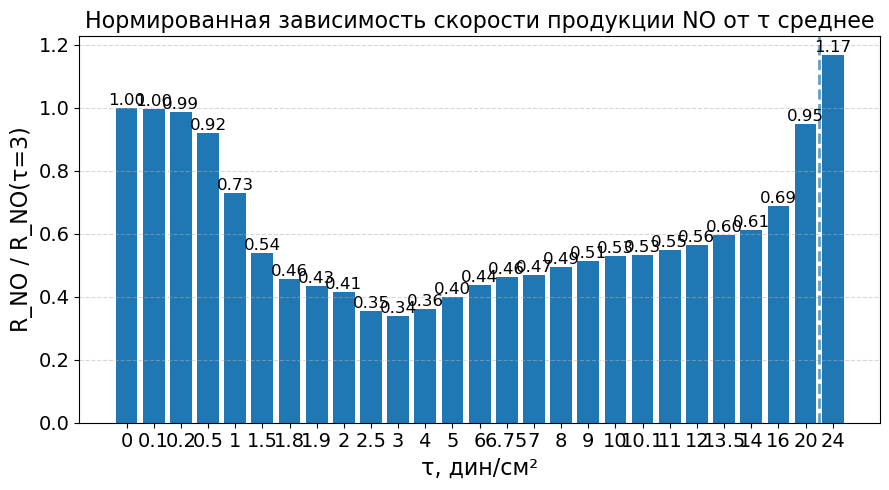

CPU times: user 439 ms, sys: 141 ms, total: 580 ms
Wall time: 650 ms


In [30]:
%%time
# ===== Ваши модельные данные =====

R_NO_plateau_mean = np.array(R_NO_plateau_mean)

R_NO_norm_mean = R_NO_plateau_mean / R_NO_plateau_mean[0]
print(R_NO_norm_mean)
x_pos = np.arange(len(tau_values))

plt.figure(figsize=(9,5))

plt.bar(x_pos, R_NO_norm_mean)

plt.xticks(x_pos, tau_values, fontsize=14)
plt.yticks(fontsize=14)

title_text = 'Нормированная зависимость скорости продукции NO от τ среднее'

plt.xlabel('τ, дин/см²', fontsize=16)
plt.ylabel('R_NO / R_NO(τ=3)', fontsize=16)
plt.title(title_text, fontsize=16)

plt.axvline(
    x=len(tau_values) - 1.5,
    linestyle='--',
    linewidth=2,
    alpha=0.7
)

for i, v in enumerate(R_NO_norm_mean):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

import re
file_name = re.sub(r'[^\w\-_\. ]', '_', title_text)
file_name = file_name.replace(' ', '_') + '.png'

plt.savefig(file_name, dpi=300, bbox_inches='tight')
plt.show()

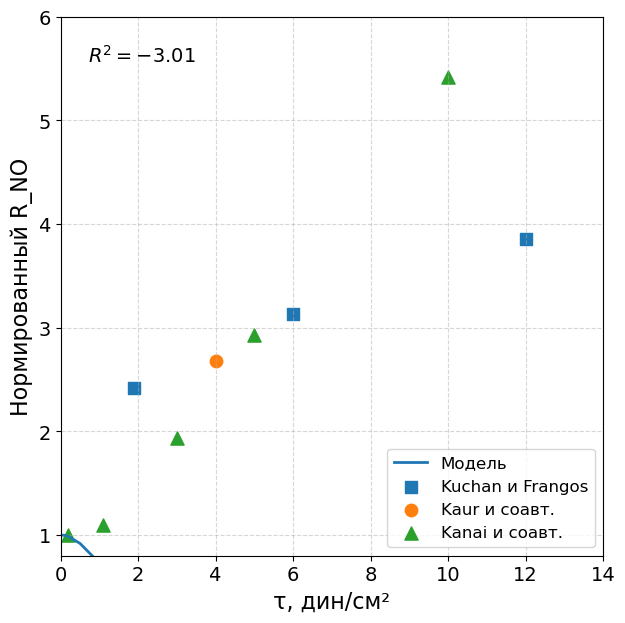

In [31]:
# ===== Экспериментальные данные =====

# Kuchan & Frangos (squares)
tau_kuchan = np.array([1.9, 6.0, 12.0])
R_kuchan   = np.array([2.42, 3.13, 3.86])

# Kaur et al. (circle)
tau_kaur = np.array([4.0])
R_kaur   = np.array([2.68])

# Kanai et al. (triangles)
tau_kanai = np.array([0.2, 1.1, 3.0, 5.0, 10.0])
R_kanai   = np.array([1.00, 1.1, 1.94, 2.93, 5.42])

# ===== Общий график =====
tau_values   = np.array(tau_values)
# ===== Общий график =====

plt.figure(figsize=(7,7))

# --- модель ---
plt.plot(
    tau_values,
    R_NO_norm_mean,
    marker=None,
    linewidth=2,
    markersize=7,
    label='Модель'
)

# --- экспериментальные точки ---
plt.scatter(
    tau_kuchan,
    R_kuchan,
    marker='s',
    s=80,
    label='Kuchan и Frangos'
)

plt.scatter(
    tau_kaur,
    R_kaur,
    marker='o',
    s=80,
    label='Kaur и соавт.'
)

plt.scatter(
    tau_kanai,
    R_kanai,
    marker='^',
    s=90,
    label='Kanai и соавт.'
)

# ===== Оформление =====

plt.xlabel('τ, дин/см²', fontsize=16)
plt.ylabel('Нормированный R_NO', fontsize=16)

title_text = ''
plt.title(title_text, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(0, 14)
plt.ylim(0.8, 6)

plt.grid(True, linestyle='--', alpha=0.5)
'''
# подписи только для модельных точек
for x, y in zip(tau_values, R_NO_norm):
    plt.text(
        x,
        y,
        f"{y:.2f}",
        ha='center',
        va='bottom',
        fontsize=11
    )
'''
plt.legend(fontsize=12)



#===== Расчет R^2 ===== 

# ===== объединяем эксперимент =====
tau_exp = np.concatenate([
    tau_kuchan,
    tau_kaur,
    tau_kanai
])

R_exp = np.concatenate([
    R_kuchan,
    R_kaur,
    R_kanai
])

# ===== модель в тех же точках =====
R_model_interp = np.interp(tau_exp, tau_values, R_NO_norm_mean)

# ===== R^2 mape =====
r2 = r2_score(R_exp, R_model_interp)

mape = np.mean(
    np.abs((R_exp - R_model_interp) / R_exp)
) * 100

plt.text(
    0.05,
    0.95,
    f"$R^2 = {r2:.2f}$",
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment='top'
)
# ===== Сохранение =====

file_name = re.sub(r'[^\w\-_\. ]', '_', title_text)
file_name = file_name.replace(' ', '_') + '.png'

plt.savefig(file_name, dpi=300, bbox_inches='tight')

plt.show()

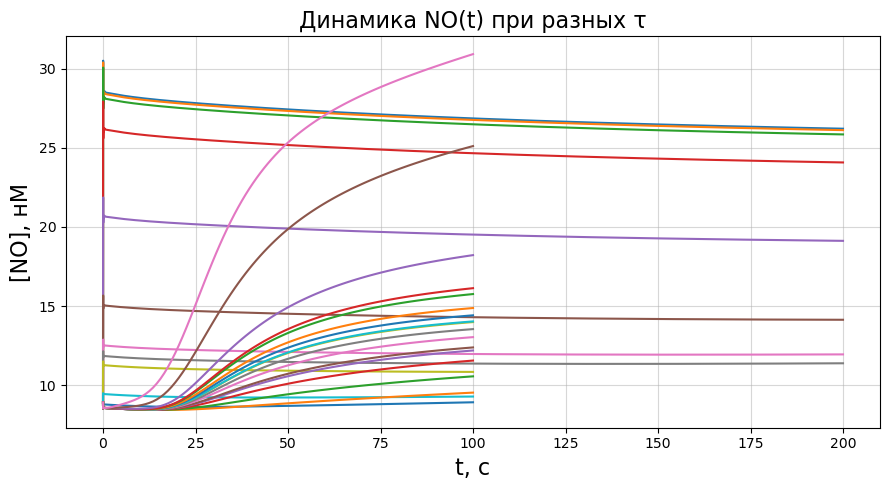

In [32]:
plt.figure(figsize=(9,5))

for tau in tau_values:
    sol = solutions_no[tau]
    t = sol.t
    NO = sol.y[4] * 1e9  # в нМ
    
    plt.plot(t, NO, label=f'τ = {tau}')

plt.xlabel('t, c', fontsize=16)
plt.ylabel('[NO], нМ', fontsize=16)
plt.title('Динамика NO(t) при разных τ', fontsize=16)

#plt.legend(fontsize=14)
plt.grid(alpha=0.5)
plt.tight_layout()

plt.savefig('NO_dynamics_tau_0_12.png', dpi=300, bbox_inches='tight')
plt.show()

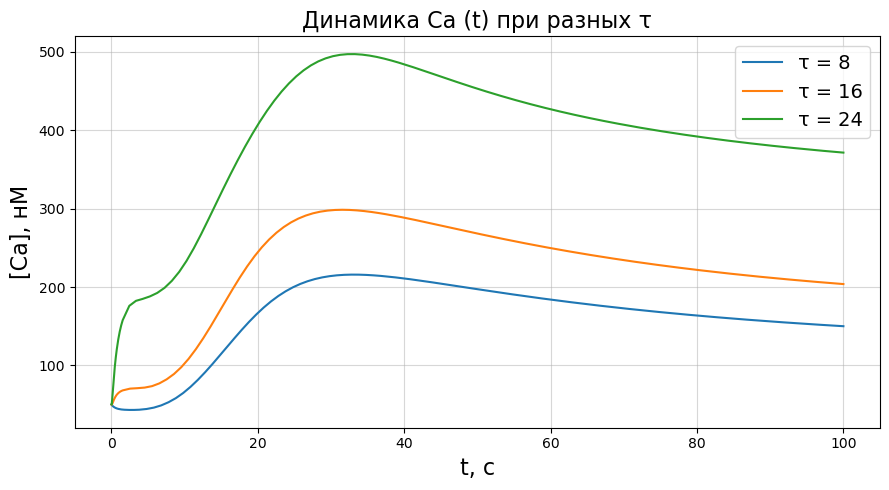

In [33]:
plt.figure(figsize=(9,5))

for tau in [8,16, 24]:
    sol = solutions_Ca[tau]
    t = sol.t
    Ca = sol.y[0] * 1e9  # в нМ
    
    plt.plot(t, Ca, label=f'τ = {tau}')

plt.xlabel('t, c', fontsize=16)
plt.ylabel('[Ca], нМ', fontsize=16)
plt.title('Динамика Ca (t) при разных τ', fontsize=16)

plt.legend(fontsize=14)
plt.grid(alpha=0.5)
plt.tight_layout()

plt.savefig('Ca_dynamics_tau.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
%%time

tau_values_ = [0, 12]

Ca_plateau = []
NO_plateau = []
R_NO_plateau = []
R_NO_plateau_mean = []
R_NO_max_time = []
solutions_no = {}
solutions_Ca = {}
t_total = 900
for tau in tqdm(tau_values_):
    
    # ===== Ca =====
    sol_ca = solve_ivp(
        fun=lambda t, y: ca_model(t, y, vessel_type, tau),
        t_span=(0, t_total),
        y0=y0,
        max_step=0.5,
        method="BDF",
        dense_output=True
    )
    
    t_ca = sol_ca.t
    Ca = sol_ca.y[0]
    
    # плато Ca
    Ca_ss = np.mean(Ca[-100:])
    Ca_plateau.append(Ca_ss)
    
    # ===== Интерполяция Ca =====
    Ca_interp = lambda t: sol_ca.sol(t)[0]
    
    # ===== NO =====
    sol_no = solve_ivp(
        fun=lambda t, y: no_model(t, y, Ca_interp, vessel_type, tau),
        t_span=(0, t_total),
        y0=y0_no,
        max_step=0.05,
        method="BDF"
    )
    
    NO = sol_no.y[4]  
    solutions_no[tau] = sol_no
    solutions_Ca[tau] = sol_ca
    # плато NO
    NO_ss = np.mean(NO[-10:])
    NO_plateau.append(NO_ss)
    # ===== R_NO =====
    t_no = sol_no.t
    eNOS_CaM = sol_no.y[1]
    eNOS_CaM_star = sol_no.y[2]

    Upsilon_base = 300.0
    sigma = 1
    delta_like = 400.0 * np.exp(-(tau**2) / (2 * sigma**2))
    Upsilon = Upsilon_base + delta_like
    phi = 9.0
    R_NO = Upsilon * (eNOS_CaM + phi * eNOS_CaM_star)
    
    # плато NO
    R_NO_ss_mean = np.mean(R_NO[-10:])
    R_NO_ss = np.max(R_NO)
    R_NO_plateau.append(R_NO_ss)
    R_NO_plateau_mean.append(R_NO_ss_mean)
    
    idx_max = np.argmax(R_NO)
    t_max_R_NO = t_no[idx_max]
    R_NO_max_time.append(t_max_R_NO)
print(R_NO_max_time)

100%|█████████████████████████████████████████████| 2/2 [00:02<00:00,  1.10s/it]

[np.float64(0.0), np.float64(900.0)]
CPU times: user 2.2 s, sys: 18 ms, total: 2.21 s
Wall time: 2.2 s


In [35]:
# ===== Экспериментальные данные =====

t_exp_no_shear = np.array([0.4e4, 0.7e4, 1.4e4, 2.2e4, 4.3e4, 8.6e4])

NO_exp_no_shear = np.array([
    0.04,
    0.001,
    0.045,
    0.13,
    0.165,
    0.32
])

t_exp_12 = np.array([0.4e4, 0.7e4, 1.4e4, 2.2e4, 4.3e4, 8.6e4])

NO_exp_12 = np.array([
    0.135,
    0.112,
    0.17,
    0.29,
    0.54,
    1.00
])

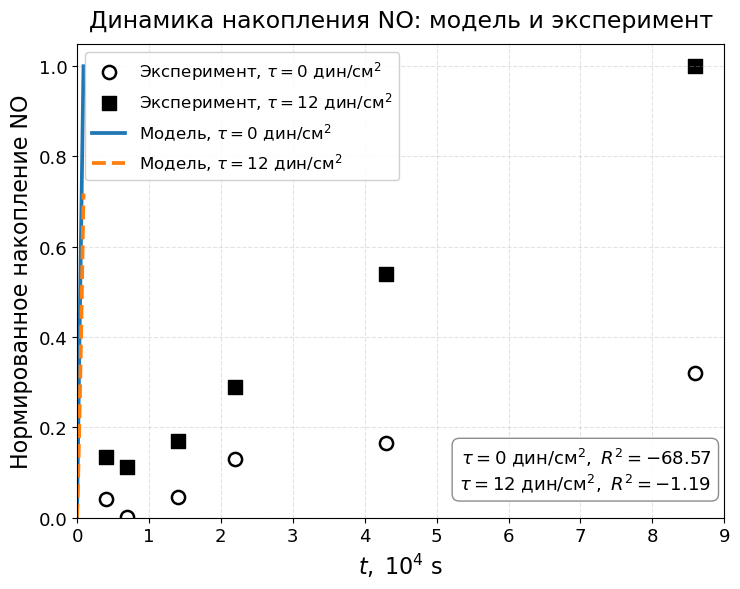

In [36]:
fig, ax = plt.subplots(figsize=(7.5, 6))

time_scale = 1e4

# =========================================
# Экспериментальные данные
# =========================================

ax.scatter(
    t_exp_no_shear / time_scale,
    NO_exp_no_shear,
    marker='o',
    s=90,
    facecolors='white',
    edgecolors='black',
    linewidth=1.8,
    label=r'Эксперимент, $\tau = 0\ \mathrm{дин/см^2}$'
)

ax.scatter(
    t_exp_12 / time_scale,
    NO_exp_12,
    marker='s',
    s=90,
    color='black',
    label=r'Эксперимент, $\tau = 12\ \mathrm{дин/см^2}$'
)

# =========================================
# Модель
# =========================================

results = {}
all_integrals = []

for tau in [0, 12]:

    sol = solutions_no[tau]

    t = sol.t
    NO = sol.y[4] * 1e9  # nM

    NO_integral = cumulative_trapezoid(NO, t, initial=0)

    results[tau] = (t, NO_integral)
    all_integrals.append(NO_integral)

global_max = np.max(np.concatenate(all_integrals))

for tau, linestyle in zip([0, 12], ['-', '--']):

    t, NO_integral = results[tau]
    NO_norm = NO_integral / global_max

    ax.plot(
        t / time_scale,
        NO_norm,
        linewidth=2.7,
        linestyle=linestyle,
        label=rf'Модель, $\tau = {tau}\ \mathrm{{дин/см^2}}$'
    )

# =========================================
# Метрики
# =========================================

metrics = {}

for tau in [0, 12]:

    t_model, NO_integral = results[tau]
    R_model_tau = NO_integral / global_max

    if tau == 0:
        t_exp_tau = t_exp_no_shear
        R_exp_tau = NO_exp_no_shear
    else:
        t_exp_tau = t_exp_12
        R_exp_tau = NO_exp_12

    R_model_interp = np.interp(t_exp_tau, t_model, R_model_tau)
    r2_tau = r2_score(R_exp_tau, R_model_interp)

    metrics[tau] = r2_tau

# =========================================
# Оформление
# =========================================

ax.set_xlabel(r'$t,\;10^4\ \mathrm{s}$', fontsize=16)
ax.set_ylabel('Нормированное накопление NO', fontsize=16)

ax.set_title('Динамика накопления NO: модель и эксперимент', fontsize=17, pad=12)

ax.set_xlim(0, 9)
ax.set_ylim(0, 1.05)

ax.tick_params(axis='both', labelsize=13)

ax.grid(alpha=0.35, linestyle='--')

# Легенда
legend = ax.legend(
    fontsize=12,
    frameon=True,
    loc='upper left'
)
legend.get_frame().set_alpha(0.92)

# Метрики
ax.text(
    0.98,
    0.05,
    rf'$\tau = 0\ \mathrm{{дин/см^2}},\ R^2 = {metrics[0]:.2f}$' + '\n' +
    rf'$\tau = 12\ \mathrm{{дин/см^2}},\ R^2 = {metrics[12]:.2f}$',
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(
        facecolor='white',
        edgecolor='gray',
        alpha=0.9,
        boxstyle='round,pad=0.4'
    )
)

plt.tight_layout()

plt.savefig(
    'NO_accumulation_global_normalization_metrics.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [41]:
%%time

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from tqdm import tqdm

# =========================================================
# SAFE NUMBERS
# =========================================================

def sanitize(y):

    y = np.array(y, dtype=float)

    # NaN -> 0
    y = np.nan_to_num(
        y,
        nan=0.0,
        posinf=1e6,
        neginf=0.0
    )

    # отрицательные концентрации запрещаем
    y = np.maximum(y, 0.0)

    # слишком большие значения режем
    y = np.minimum(y, 1e6)

    return y


# =========================================================
# SAFE Ca MODEL
# =========================================================

def ca_model_safe(t, y, vessel_type, tau, piezo_on=True):

    y = sanitize(y)

    # ---------------------------------------------
    # отключение Piezo
    # ---------------------------------------------

    if not piezo_on:

        global piezo1_open_probability

        original_func = piezo1_open_probability

        piezo1_open_probability = (
            lambda tau_dyn_cm2, vessel_type: 0.0
        )

        dydt = ca_model(
            t,
            y,
            vessel_type,
            tau
        )

        piezo1_open_probability = original_func

    else:

        dydt = ca_model(
            t,
            y,
            vessel_type,
            tau
        )

    dydt = sanitize(dydt)

    # запрещаем уход ниже 0
    for i in range(len(y)):

        if y[i] <= 0 and dydt[i] < 0:
            dydt[i] = 0.0

    return dydt


# =========================================================
# SAFE NO MODEL
# =========================================================

def no_model_safe(
    t,
    y,
    Ca_interp,
    vessel_type,
    tau,
    kinases_on=True
):

    y = sanitize(y)

    # ---------------------------------------------
    # отключение kinase cascade
    # ---------------------------------------------

    if not kinases_on:

        y = y.copy()

        # AKT*
        y[6] = 0.0

        # PKC*
        y[7] = 0.0

        # G
        y[8] = 0.0

        # IP3
        y[9] = 0.0

        # PIP2
        y[10] = 0.0

        # PIP3
        y[11] = 0.0

    dydt = no_model(
        t,
        y,
        Ca_interp,
        vessel_type,
        tau
    )

    dydt = sanitize(dydt)

    # фиксируем kinase variables в нуле
    if not kinases_on:

        dydt[6] = 0.0
        dydt[7] = 0.0
        dydt[8] = 0.0
        dydt[9] = 0.0
        dydt[10] = 0.0
        dydt[11] = 0.0

    return dydt


# =========================================================
# CASES
# =========================================================

cases = {

    "full_model": {
        "piezo": True,
        "kinases": True
    },

    "no_piezo": {
        "piezo": False,
        "kinases": True
    },

    "no_kinases": {
        "piezo": True,
        "kinases": False
    }
}

# =========================================================
# τ
# =========================================================

tau_values = [
    0,
    1,
    2,
    3,
    5,
    6,
    8,
    10,
    12,
    13.5
]

# =========================================================
# RESULTS
# =========================================================

all_results = {}

# =========================================================
# MAIN LOOP
# =========================================================

for case_name, settings in cases.items():

    print(f"\n===== {case_name} =====")

    Ca_plateau = []
    NO_plateau = []

    for tau in tqdm(tau_values):

        t_total = 200 if tau < 2 else 80

        max_step = 0.5 if tau < 2 else 1.0

        # =================================================
        # Ca
        # =================================================

        sol_ca = solve_ivp(

            fun=lambda t, y: ca_model_safe(
                t,
                y,
                vessel_type,
                tau,
                piezo_on=settings["piezo"]
            ),

            t_span=(0, t_total),

            y0=sanitize(y0),

            method="BDF",

            max_step=max_step,

            rtol=1e-6,

            atol=1e-9,

            dense_output=True
        )

        # если solver умер
        if not sol_ca.success:

            print(f"FAILED Ca: tau={tau}")
            print(sol_ca.message)

            Ca_plateau.append(np.nan)
            NO_plateau.append(np.nan)

            continue

        # =================================================
        # Ca plateau
        # =================================================

        Ca = sanitize(sol_ca.y[0])

        Ca_ss = np.mean(Ca[-100:])

        Ca_plateau.append(Ca_ss)

        # =================================================
        # interpolation
        # =================================================

        def Ca_interp(t):

            val = sol_ca.sol(t)[0]

            return max(val, 0.0)

        # =================================================
        # NO
        # =================================================

        sol_no = solve_ivp(

            fun=lambda t, y: no_model_safe(
                t,
                y,
                Ca_interp,
                vessel_type,
                tau,
                kinases_on=settings["kinases"]
            ),

            t_span=(0, t_total),

            y0=sanitize(y0_no),

            method="BDF",

            max_step=max_step,

            rtol=1e-6,

            atol=1e-9
        )

        if not sol_no.success:

            print(f"FAILED NO: tau={tau}")
            print(sol_no.message)

            NO_plateau.append(np.nan)

            continue

        # =================================================
        # NO plateau
        # =================================================

        NO = sanitize(sol_no.y[4])

        NO_ss = np.mean(NO[-100:])

        NO_plateau.append(NO_ss)

    # =====================================================
    # SAVE
    # =====================================================

    all_results[case_name] = {

        "tau_values": tau_values,

        "Ca_plateau": Ca_plateau,

        "NO_plateau": NO_plateau
    }

print("\nDONE")


===== full_model =====


100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 11.62it/s]



===== no_piezo =====


100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 14.28it/s]



===== no_kinases =====


100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 11.90it/s]


DONE
CPU times: user 2.39 s, sys: 89.6 ms, total: 2.48 s
Wall time: 2.4 s


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =========================================================
# 1. СЦЕНАРИИ τ(t)
# =========================================================

def tau_const(t):
    return 5.0

def tau_osc_3(t):
    return 5.0 + 3.0 * np.sin(2 * np.pi * 1.0 * t)

def tau_osc_5(t):
    return 5.0 + 4.0 * np.sin(2 * np.pi * 1.0 * t)

def tau_osc_5_2hz(t):
    return 5.0 + 4.0 * np.sin(2 * np.pi * 2.0 * t)
def tau_osc_5_4hz(t):
    return 5.0 + 4.0 * np.sin(2 * np.pi * 4.0 * t)

cases = [
    ("const τ=5", tau_const),
    ("osc A=3, f=1Hz", tau_osc_3),
    ("osc A=4, f=1Hz", tau_osc_5),
    ("osc A=4, f=2Hz", tau_osc_5_2hz),
    ("osc A=4, f=4Hz", tau_osc_5_4hz),
]

# =========================================================
# 2. РЕЗУЛЬТАТЫ
# =========================================================

NO_results = []
Ca_results = []

t_span = (0, 250)
y0_local = y0
y0_no_local = y0_no

for name, tau_func in tqdm(cases):

    # ===== Ca =====
    sol_ca = solve_ivp(
        fun=lambda t, y: ca_model(t, y, vessel_type, tau_func(t)),
        t_span=t_span,
        y0=y0_local,
        method="BDF",
        max_step=1.0,
        dense_output=True
    )

    Ca = sol_ca.y[0] * 1e9
    Ca_ss = np.mean(Ca[-100:])

    Ca_interp = lambda t: sol_ca.sol(t)[0]

    # ===== NO =====
    sol_no = solve_ivp(
        fun=lambda t, y: no_model(t, y, Ca_interp, vessel_type, tau_func(t)),
        t_span=t_span,
        y0=y0_no_local,
        method="BDF",
        max_step=1.0
    )

    NO = sol_no.y[4] * 1e9
    NO_ss = np.mean(NO[-100:])

    Ca_results.append(Ca_ss)
    NO_results.append(NO_ss)

    print(f"{name}: NO = {NO_ss:.2f} nM, Ca = {Ca_ss:.2f} nM")


  0%|                                                     | 0/5 [00:00<?, ?it/s]

const τ=5: NO = 11.74 nM, Ca = 118.31 nM


 40%|██████████████████                           | 2/5 [00:00<00:00,  5.10it/s]

osc A=3, f=1Hz: NO = 11.02 nM, Ca = 112.69 nM


 60%|███████████████████████████                  | 3/5 [00:00<00:00,  3.74it/s]

osc A=4, f=1Hz: NO = 10.49 nM, Ca = 109.52 nM


 80%|████████████████████████████████████         | 4/5 [00:01<00:00,  2.62it/s]

osc A=4, f=2Hz: NO = 13.07 nM, Ca = 109.42 nM


100%|█████████████████████████████████████████████| 5/5 [00:02<00:00,  2.19it/s]

osc A=4, f=4Hz: NO = 10.49 nM, Ca = 109.45 nM


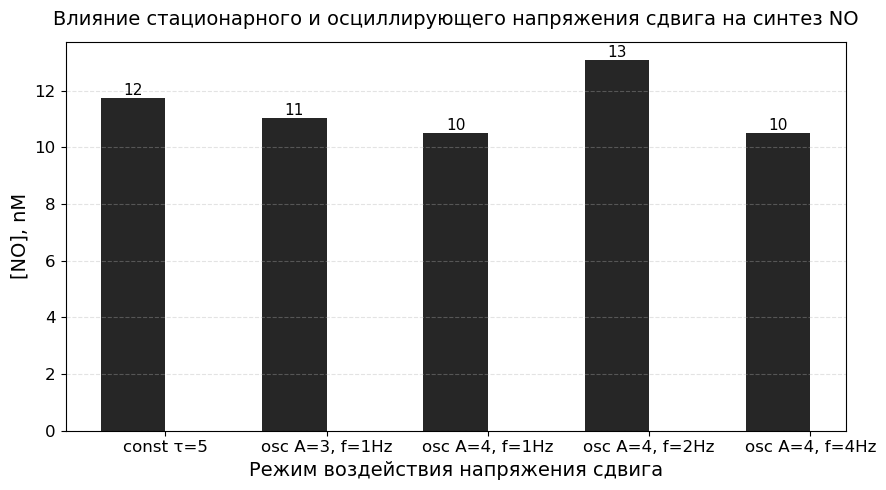

In [48]:
# =========================================================
# 3. ГРАФИК СРАВНЕНИЯ (УЛУЧШЕННЫЙ)
# =========================================================

labels = [c[0] for c in cases]
x = np.arange(len(cases))

plt.figure(figsize=(9, 5))

bars_no = plt.bar(
    x - 0.2,
    NO_results,
    width=0.4,
    label="NO",
    color="black",
    alpha=0.85
)

# ===== значения над столбцами =====
for bar in bars_no:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        color="black"
    )

# ===== оформление осей =====
plt.xticks(
    x,
    labels,
    fontsize=12
)

plt.yticks(fontsize=12)

plt.ylabel("[NO], nM", fontsize=14)
plt.xlabel("Режим воздействия напряжения сдвига", fontsize=14)

plt.title(
    "Влияние стационарного и осциллирующего напряжения сдвига на синтез NO",
    fontsize=14,
    pad=12
)

# ===== сетка =====
plt.grid(axis="y", linestyle="--", alpha=0.35)

# ===== легенда =====
#plt.legend(frameon=True, fontsize=12, loc="upper left")

plt.tight_layout()
plt.show()

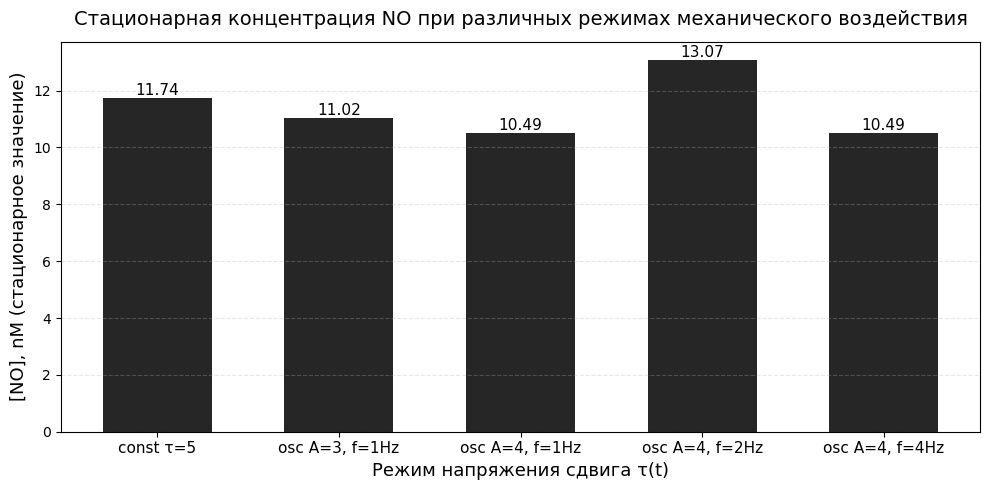

In [49]:
# =========================================================
# 3. УЛУЧШЕННЫЙ ГРАФИК СРАВНЕНИЯ РЕЖИМОВ
# =========================================================

labels = [c[0] for c in cases]
x = np.arange(len(cases))

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    NO_results,
    width=0.6,
    color="black",
    alpha=0.85
)

# ===== значения над столбцами =====
for i, bar in enumerate(bars):
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# ===== оси =====
plt.xticks(
    x,
    labels,
    fontsize=11
)

plt.ylabel("[NO], nM (стационарное значение)", fontsize=13)
plt.xlabel("Режим напряжения сдвига τ(t)", fontsize=13)

# ===== заголовок =====
plt.title(
    "Стационарная концентрация NO при различных режимах механического воздействия",
    fontsize=14,
    pad=12
)

# ===== поясняющая сетка =====
plt.grid(axis="y", linestyle="--", alpha=0.3)



plt.tight_layout()
plt.show()

In [60]:


def tau_from_vessel(vessel_type=None, t=0, units='dyn/cm2'):
    """
    Универсальное колебательное напряжение сдвига τ(t),
    не зависящее от типа сосуда.
    """

    # ===== параметры колебаний =====
    tau_mean = 5.0      # средний уровень (dyn/cm²)
    tau_amp  = 4.0      # амплитуда
    freq_hz  = 2.0      # частота (Гц)

    # ===== колебательный сигнал =====
    tau = tau_mean + tau_amp * np.sin(2 * np.pi * freq_hz * t)

    # ===== пересчёт единиц (если нужно) =====
    if units == 'Pa':
        tau *= 0.1  # dyn/cm² -> Pa
    elif units == 'dyn/cm2':
        pass
    else:
        raise ValueError("units must be 'dyn/cm2' or 'Pa'")

    return tau

In [64]:
#модель изменения концентрации Ca внутри клетки Atherosclerosis and calcium signalling in endothelial cells
def ca_model(t, y, vessel_type, tau=5):
    Ca_c, Ca_s, Cab, N_open, N_inact, N_cl, IP3, G, PIP2 = y
    tau_shear = tau_from_vessel(vessel_type, t, units='dyn/cm2') 
    tau_inact = 0.0656 # Piezo1, a mechanically activated ion channel, is required for vascular development in mice
    k_inact = 1.0 / tau_inact
    tau_rec = 0.024 # Transduction of repetitive mechanical stimuli by Piezo1 and Piezo2 ion channels
    k_rec = 1.0 / tau_rec
    tau_open  = 1
    Vc = 1835e-15 # л³  The shape of the EC varies along the vascular tree, but they are generally thin and slightly elongated, their dimensions described to be roughly 30–50 µm in length, 10–30 µm wide and a thickness of 0.1–10 µm
    #Endothelial cell subpopulations in vitro: cell volume, cell cycle, and radiosensitivity 1,009 +- 170   1,835 +- 282
    N_s = 1 # каналов на клетку, 1-2 канала/мкм,2 Piezo1 ion channels inherently function as independent mechanotransducers
    V_um3 = Vc * 1e15

    # площадь поверхности в мкм^2
    S = 4 * math.pi * ((3 * V_um3) / (4 * math.pi)) ** (2/3)
    N_total = round(N_s * S,0) # каналов на клетку, 1-2 канала/мкм,2 Piezo1 ion channels inherently function as independent mechanotransducers
    # ===== P_0 =====
    p_o = piezo1_open_probability(tau_shear,vessel_type)
    # ===== k_open с Wiesner sensitization A mathematical model of the cytosolic-free calcium response in endothelial cells to fluid shearstress =====
    k_open = 1 / tau_open * p_o # A mathematical model of the cytosolic-free calcium response in endothelial cells to fluid shearstress в статье говорится, что константа открытия как раз пропорциональна вероятности открытия

    dN_open_dt  = k_open * N_cl - k_inact * N_open
    dN_inact_dt = k_inact * N_open - k_rec * N_inact
    dN_cl_dt    = k_rec * N_inact - k_open * N_cl

    R, T_phys, F = 8.314, 310.0, 96485.0
    Vm = -40e-3 # V Contributions of K+, Na+, and Cl- to the membrane potential of intact hamster vascular endothelial cells
    Ca_o = 1.5e-3
    z = 2.0

    
    f_g_tot = 41.3e-12 #Voltage gating of mechanosensitive PIEZO channels 41.3 ± 0.9 pS
    Na_o = 145*1e-3
    N_o = 5*1e-3
    PCa = 1.06 # PCa/PCs ratio of 1.21 Piezo1 ion channel pore properties are dictated by C-terminal region
    #PK > PCs 1.0: 0.88 Ionic Selectivity and Permeation Properties of Human PIEZO1 Channels
    PNa = 1
    PK = 1.22
    f_Ca = 4 * PCa*Ca_o/ (4 * PCa*Ca_o + PNa*Na_o + PK * N_o)
    P_tot = f_g_tot * R * T_phys / (z**2 * F**2 * Ca_o)
    # Поток через все открытые каналы (моль/с) A mathematical model of the cytosolic-free calcium response in endothelial cells to fluid shearstress
    exp_term = np.exp(-z * F * Vm / (R * T_phys))
    q_in_i = -N_open * P_tot * f_Ca * z**2 * F**2 * Vm / (R * T_phys) * (Ca_c - Ca_o * exp_term) / (1.0 - exp_term)
    q_in = q_in_i / (z * F * Vc)

    # ===== 8. AKT & PKC dynamics =====
    k_pkc = 0.1155
    k_akt = 0.1155
    Lambda = 15
    k_a = 0.017      # ka
    k_d = 0.15       # kd
    G_t = 0.33*1e-6
    rr = 10
    alpha = 8.37
    K_cp = 0.002*1e6
    M_ATP = 0.7937
    k_pip2_minus = 0.7024
    k_1p = 0.021
    alpha_PI3K = 2.5
    eta = 0.003
    delta = 24
    k_2p = 0.022
    k_pip2_plus = k_1p + k_2p
    mu1 = 0.2
    PIP2_t = 10*1e-6


    PIP3_min = 0.0031 * PIP2_t
    R_star = np.tanh(np.pi * tau_shear / Lambda)
    PIP3_max = 0.031 * PIP2_t
    dG_dt = k_a * R_star * (G_t - G) - k_d * G
    
    rf = alpha * K_cp * M_ATP * G

    dIP3_dt = rf * PIP2  - mu1 * IP3

    dPIP2_dt = - (rf + rr) * PIP2 - rr * IP3 + rr * PIP2_t - k_pip2_plus * PIP2 + k_pip2_minus * IP3



    k3 = 6.64 #6.64
    k5 = 1e-1
    K_CICR = 0.0
    K2 = 0.2e-6
    V_r = 3.5
    k4 = 5.0e-6
    K3 = 0.15e-6
    
    q_rel = k3 * Ca_c / (K_CICR + Ca_c + 1e-30) * (IP3 / (K2 + IP3))**3 * Ca_s #Atherosclerosis and calcium signalling in endothelial cells
    q_SERCA = k4 * (Ca_c / (K3 + Ca_c))**2 #Atherosclerosis and calcium signalling in endothelial cells

    q_out, q_b = calcium_fluxes(Ca_c, Cab)

    kCCE = 15e-1
    Cas0 = 2.828e-3
    q_cce = kCCE * (Cas0 - Ca_s) * (Ca_o - Ca_c) #Atherosclerosis and calcium signalling in endothelial cells
    k8 = 24.7e-6
    q_sink = k8 * Ca_c / (1.0 + Ca_c)
    q_leak = k5 * Ca_s**2
    dCa_c_dt = q_rel + q_in + q_cce + q_leak - q_SERCA  - q_out - q_b  - q_sink  #Atherosclerosis and calcium signalling in endothelial cells
    dCa_s_dt = -V_r * (q_rel - q_SERCA + q_leak) #Atherosclerosis and calcium signalling in endothelial cells
    dCab_dt = q_b #Atherosclerosis and calcium signalling in endothelial cells
    '''print(
    f"t={t:.2f} | Ca={Ca_c*1e9:.3f} нM | "
    f"rel={q_rel*1e6:.3f} in={q_in*1e6:.3f} cce={q_cce*1e6:.3f} "
    f"leak={q_leak*1e6:.3f} SERCA={q_SERCA*1e6:.3f} "
    f"out={q_out*1e6:.3f} buf={q_b*1e6:.3f} sink={q_sink*1e6:.3f}")'''
    return [dCa_c_dt, dCa_s_dt, dCab_dt, dN_open_dt, dN_inact_dt, dN_cl_dt, dIP3_dt, dG_dt, dPIP2_dt]

In [65]:
# Модель NO
#Shear‑Induced Nitric Oxide Production by Endothelial Cells
def no_model(t, y, Ca_profile, vessel_type, tau=5):
    Ca4CaM, eNOS_CaM, eNOS_CaM_star, eNOS0cav, NO, cGMP, AKT_star, PKC_star, G, IP3, PIP2, PIP3 = y
    tau_shear = tau_from_vessel(vessel_type, t, units='dyn/cm2') 
    # ===== Входные параметры =====
    Ca = Ca_profile(t) # + 5*1e-9                      # моль/л (M)


    # CaM (Eq.17): первоначально в µM → умножаем на 1e-6
    k_Ca4_CaM   = 100.0        # s⁻¹
    beta        = 2.7
    theta       = 0.0045 #0.0045
    K_d_CaM     = 1e-6  # 1 µM → 1e-6 M
    CaM_tot     = 30e-6  # 30 µM → 30e-6 M

    # eNOS‑CaM (Eq.18)
    k_plus_CaM      = 7.5      # s⁻¹
    k_minus_CaM     = 0.01     # s⁻¹
    K_0_5_CaM       = 3e-6  # 3 µM → 3e-6 M
    eNOS_tot        = 0.04e-6 # 0.04 µM → 0.04e-6 M

    # eNOS‑CaM* (Eq.19)
    k_eAKT_max      = 0.004        # s⁻¹
    k_eAKT_minus    = 2.22e-4      # s⁻¹
    k_eAKT_plus = k_eAKT_max * AKT_star

    # PKC inhibition (Eq.20)
    k_Thr_plus      = 0.002
    k_Thr_minus     = 2.22e-4

    # NO production (Eq.22–26)
    Upsilon_base         = 300.0#300.0
    sigma = 1
    A = 700.0
    delta_like = A  * np.exp(-(tau**2) / (2 * sigma**2))
    Upsilon = Upsilon_base + delta_like
    phi             = 9.0
    R_max_NO        = 0.022
    lambda_NO       = 382.0

    # a0, a1, b1, g0, g1: изначально в nM → нужно пересчитать в M
    a0 = 1200.16 * 1e-18   # nM² → M²: 1 nM² = 1e-18 M²
    a1  = 37.33 * 1e-9      # nM  → 1e-9 M
    b1  = 15.15 * 1e-9    # nM  → 1e-9 M
    g0 = 4.8 * 1e-18      # nM² → 1e-18 M²
    g1  = 35.33  * 1e-9    # nM  → 1e-9 M

    sGC_tot         = 0.1e-6   # 0.1 µM → 0.1e-6 M

    # cGMP (Eq.27)
    V_max_cGMP      = 1.26e-6         # µM/s → нужно в M/s

    X               = 0.0695          # s⁻¹ 
    K_cGMP          = 2e-6    # 2 µM → 2e-6 M (в M)

    # ===== 8. AKT & PKC dynamics =====
    k_pkc = 0.1155
    k_akt = 0.1155
    Lambda = 15
    k_a = 0.017      # ka
    k_d = 0.15       # kd
    G_t = 0.33*1e-6
    rr = 10
    alpha = 8.37
    K_cp = 0.002*1e6
    M_ATP = 0.7937
    k_pip2_minus = 0.7024
    k_1p = 0.021
    alpha_PI3K = 2.5
    eta = 0.003
    delta = 24
    k_2p = 0.022 #0.022 
    k_pip2_plus = k_1p / (1 + alpha_PI3K) * (1 + alpha_PI3K * np.exp(-eta * t)*np.tanh(np.pi * tau_shear / delta)) + k_2p
    k_pip2_plus = k_1p + k_2p
    mu1 = 0.2
    PIP2_t = 10*1e-6

    AKT = 1 - AKT_star
    PKC = 1 - PKC_star
    PIP3_min = 0.0031 * PIP2_t
    PIP3_max = 0.031 * PIP2_t
    R_star = np.tanh(np.pi * tau_shear / Lambda)
    kpkc = 0.1 * k_pkc * (PIP3 - PIP3_min)/(PIP3_max - PIP3_min)
    kakt = 0.1 * k_akt * (PIP3 - PIP3_min)/(PIP3_max - PIP3_min)

    # ===== 1. Ca4‑CaM =====
    dCa4CaM_dt = k_Ca4_CaM * (theta * Ca**beta / (K_d_CaM**beta + Ca**beta) * CaM_tot -  Ca4CaM) # The Relationship between the Free Concentrations of Ca21 and Ca21-calmodulin in Intact Cells*

    # ===== 2. eNOS_cav =====
    eNOS_cav = eNOS_tot - eNOS_CaM - eNOS_CaM_star - eNOS0cav

    # ===== 4. eNOS‑CaM* (phosphorylation by AKT) =====
    d_eNOS_CaM_star_dt  = k_eAKT_plus * eNOS_CaM - k_eAKT_minus * eNOS_CaM_star

    # ===== 3. eNOS‑CaM =====
    d_eNOS_CaM_dt = k_plus_CaM * (Ca4CaM / (K_0_5_CaM + Ca4CaM)) * eNOS_cav- k_minus_CaM * eNOS_CaM - d_eNOS_CaM_star_dt
    
    # ===== 5. PKC inhibition → eNOS0cav =====
    d_eNOS0cav_dt = k_Thr_plus * PKC_star * eNOS_cav - k_Thr_minus * eNOS0cav
    
    # ===== 6. NO production =====
    R_NO        = Upsilon * (eNOS_CaM + phi * eNOS_CaM_star)
    denom_sGC   = a0 + a1 * NO + NO**2
    Q_sGC       = R_max_NO * (NO**2 + b1 * NO) / denom_sGC * sGC_tot
    d_NO_dt     = R_NO - Q_sGC - lambda_NO * NO
    
    # ===== 7. cGMP =====
    dcGMP_dt    = V_max_cGMP * (g0 + g1 * NO + NO**2) / (a0 + a1 * NO + NO**2) - X * (cGMP**2 / (K_cGMP + cGMP))

    K_cGMP = 0.55*1e-6#Mathematical Modeling of the Nitric Oxide/cGMP Pathways in the Vascular Smooth Muscle Cell
    dcGMP_dt    = V_max_cGMP * (g0 + g1 * NO + NO**2) / (a0 + a1 * NO + NO**2) - X * (cGMP**2 / (K_cGMP**2  + cGMP**2))
    # ===== 8. AKT & PKC dynamics =====
    dG_dt = k_a * R_star * (G_t - G) - k_d * G
    rf = alpha * K_cp * M_ATP * G
    dIP3_dt = rf * PIP2 - mu1 * IP3
    dPIP2_dt = - (rf + rr) * PIP2 - rr * IP3 + rr * PIP2_t - k_pip2_plus * PIP2 + k_pip2_minus * PIP3
    dPIP3_dt = k_pip2_plus * PIP2 - k_pip2_minus * PIP3
    d_AKT_star_dt = kakt * AKT - k_akt * AKT_star
    d_PKC_star_dt = kpkc * PKC - k_pkc * PKC_star
    dPIP3_dt = k_pip2_plus * PIP2 - k_pip2_minus * PIP3

    return [
    dCa4CaM_dt,
    d_eNOS_CaM_dt,
    d_eNOS_CaM_star_dt,
    d_eNOS0cav_dt,
    d_NO_dt,
    dcGMP_dt,
    d_AKT_star_dt,
    d_PKC_star_dt,
    dG_dt,
    dIP3_dt,
    dPIP2_dt,
    dPIP3_dt
]


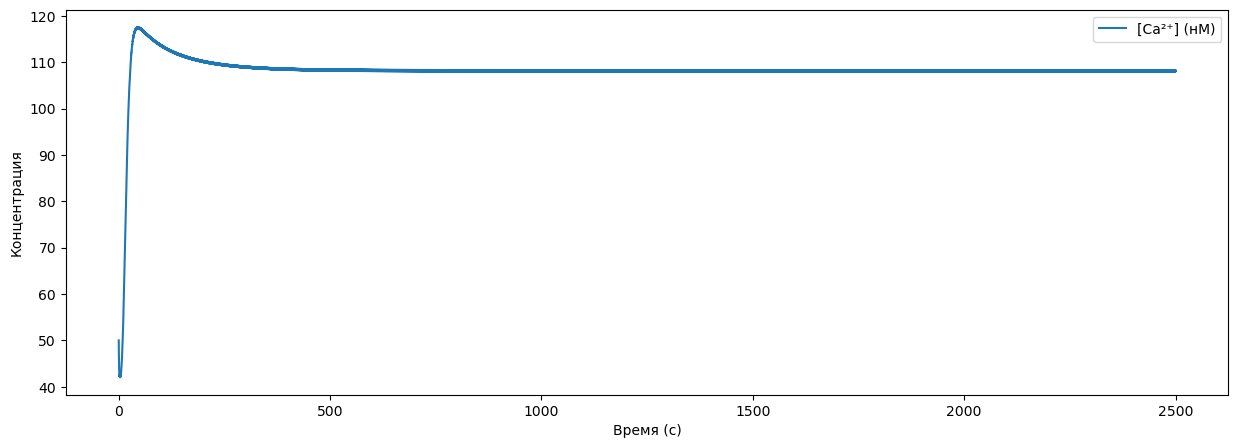

CPU times: user 5.57 s, sys: 174 ms, total: 5.74 s
Wall time: 5.71 s


In [67]:
%%time
# ===== Начальные условия =====


t_span = (0.0, 2500.0)  # время интегрирования уравнения

# ===== Функция интеграции =====
sol_ca  = solve_ivp(
    fun=lambda t, y: ca_model(t, y, vessel_type, tau),
    t_span=t_span,
    y0=y0,
    max_step=0.05,
    dense_output=True, 
    method="BDF"
)

# ===== Доступ к результатам =====
t = sol_ca.t
Ca = sol_ca.y[0]
Cas = sol_ca.y[1]
Cab = sol_ca.y[2]
N_open = sol_ca.y[3]
N_inact = sol_ca.y[4]
N_cl = sol_ca.y[5]
IP3 = sol_ca.y[6]


x = 15
y = 5
plt.figure(figsize=(x,y))
plt.plot(t, Ca*1e9, label='[Ca²⁺] (нМ)')
plt.xlabel('Время (с)')
plt.ylabel('Концентрация')
plt.legend()
plt.show()

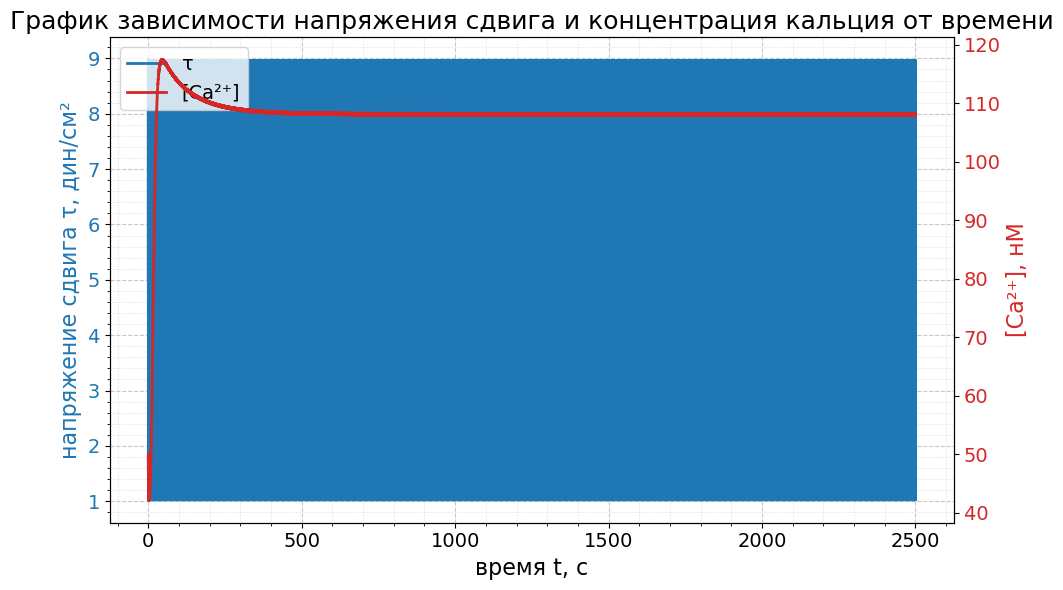

In [68]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Цвета
color_tau = 'tab:blue'
color_ca = 'tab:red'

# Первая ось Y — tau
tau_vals = np.array([tau_from_vessel(vessel_type, ti) for ti in t])
line1, = ax1.plot(t, tau_vals, label='τ', color=color_tau, linewidth=2)

ax1.set_xlabel('время t, с', fontsize=16)
ax1.set_ylabel('напряжение сдвига τ, дин/см²', fontsize=16, color=color_tau)
ax1.tick_params(axis='both', labelsize=14)
ax1.tick_params(axis='y', labelcolor=color_tau)

# Сетка
ax1.minorticks_on()
ax1.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=0.6, alpha=0.5)

# Вторая ось Y — Ca
ax2 = ax1.twinx()
line2, = ax2.plot(t, Ca * 1e9, label='[Ca²⁺]', color=color_ca, linewidth=2)

ax2.set_ylabel('[Ca²⁺], нМ', fontsize=16, color=color_ca)
ax2.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='y', labelcolor=color_ca)

# Легенда
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=14)

# Заголовок
plt.title('График зависимости напряжения сдвига и концентрация кальция от времени', fontsize=18)

plt.tight_layout()
plt.show()

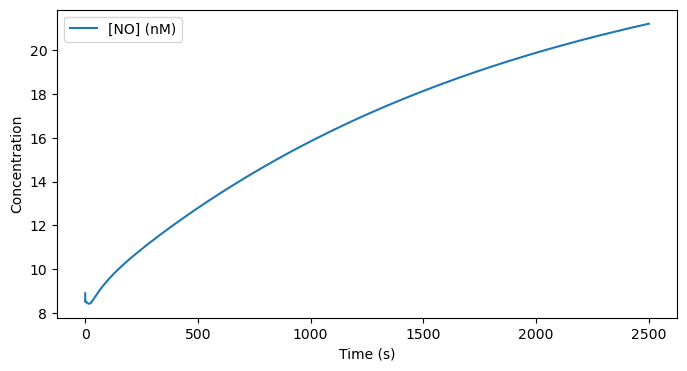

CPU times: user 3.28 s, sys: 17 ms, total: 3.3 s
Wall time: 3.29 s


In [69]:
%%time

#0.001e-6,  # NO0
sol_no = solve_ivp(
    lambda t, y: no_model(t, y, Ca_interp, vessel_type),
    t_span,
    y0_no,
    method='BDF',
    max_step=0.05,
    dense_output=True
)


t_NO = sol_no.t
NO = sol_no.y[4]
plt.figure(figsize=(8, 4))
plt.plot(t_NO, NO*1e9, label='[NO] (nM)')
plt.legend(); plt.xlabel('Time (s)'); plt.ylabel('Concentration')
plt.show()


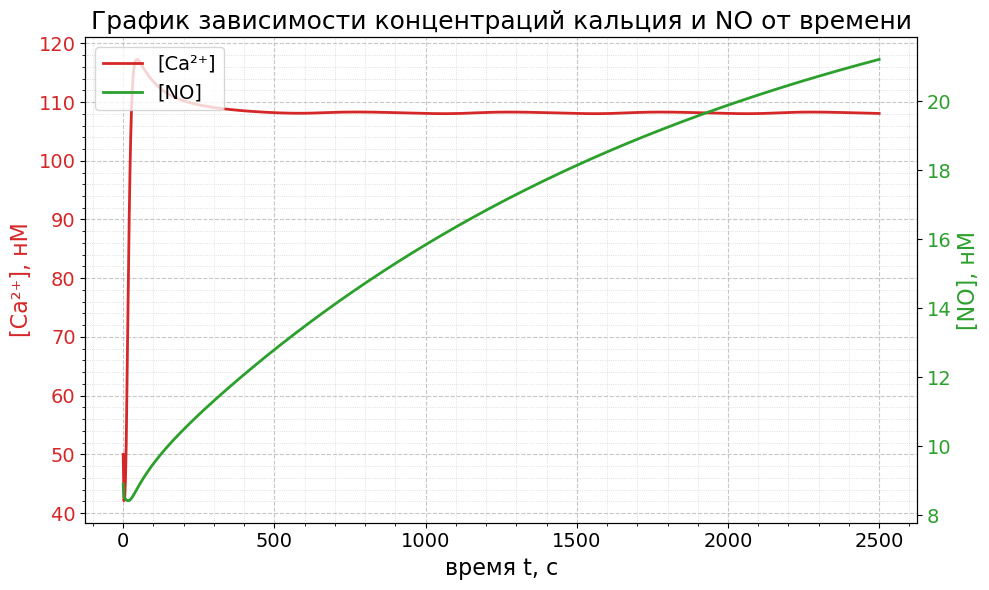

In [70]:
#График напряжения концентрации NO и концентрации кальция от времени # ===== Используем t_Ca и t_NO из решения ODE ===== 
t_Ca = sol_ca.t 
Ca = sol_ca.y[0] 
t_NO = sol_no.t 
NO = sol_no.y[4] # ===== Общий массив времени для графика ===== 
t_common = np.linspace(max(t_Ca[0], t_NO[0]), min(t_Ca[-1], t_NO[-1]), 1000) # ===== Интерполяция ===== 
f_Ca = interp1d(t_Ca, Ca*1e9, kind='linear', fill_value="extrapolate") 
f_NO = interp1d(t_NO, NO*1e9, kind='linear', fill_value="extrapolate") 
Ca_interp = f_Ca(t_common) 
NO_interp = f_NO(t_common)

# ===== Построение графика =====
fig, ax1 = plt.subplots(figsize=(10,6))

color_ca = 'tab:red'
color_no = 'tab:green'

# Ca
line1, = ax1.plot(t_common, Ca_interp, label='[Ca²⁺]', color=color_ca, linewidth=2)

ax1.set_xlabel('время t, с', fontsize=16)
ax1.set_ylabel('[Ca²⁺], нМ', fontsize=16, color=color_ca)
ax1.tick_params(axis='both', labelsize=14)
ax1.tick_params(axis='y', labelcolor=color_ca)

# Сетка
ax1.minorticks_on()
ax1.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=0.6, alpha=0.5)

# NO
ax2 = ax1.twinx()
line2, = ax2.plot(t_common, NO_interp, label='[NO]', color=color_no, linewidth=2)

ax2.set_ylabel('[NO], нМ', fontsize=16, color=color_no)
ax2.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='y', labelcolor=color_no)

# Легенда
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=14)

# Заголовок
plt.title('График зависимости концентраций кальция и NO от времени', fontsize=18)

plt.tight_layout()
plt.show()